Use to cut only a certain part of parameter space that represents a better fit

In [92]:
from escripts import edata
from escripts import eMCMC
from escripts import eplots
from matplotlib.gridspec import GridSpec
import math

In [97]:
folder = '/Users/eb35267/Desktop/code/chains/min_sig_0.3/add_dlogMcdz/broader_ICs/'
file_name = folder + '/samples.h5'

In [98]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt'
               , '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
params = eMCMC.build_param_data({'dlogMcdz':{'fit':True}, 'dsigdz':{'fit':True}})
# params = eMCMC.build_param_data({'dalphadz':{'fit':True}, 'dbetadz':{'fit':True}, 'dlogedz':{'fit':True}, 'dlogMcdz':{'fit':True}, 
#                                  'dsigdz':{'fit':True}, 'dsigdlogM':{'fit':True}, 'min_sig':{'fit':True}, 'C0':{'fit':True}, 
#                                  'C1':{'fit':True}
#                                  })

In [99]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [100]:
samples, best_fit, medians, bounds, param_labels, log_prob = my_UVLF.get_fit(backend_file = file_name, return_log_prob=True)

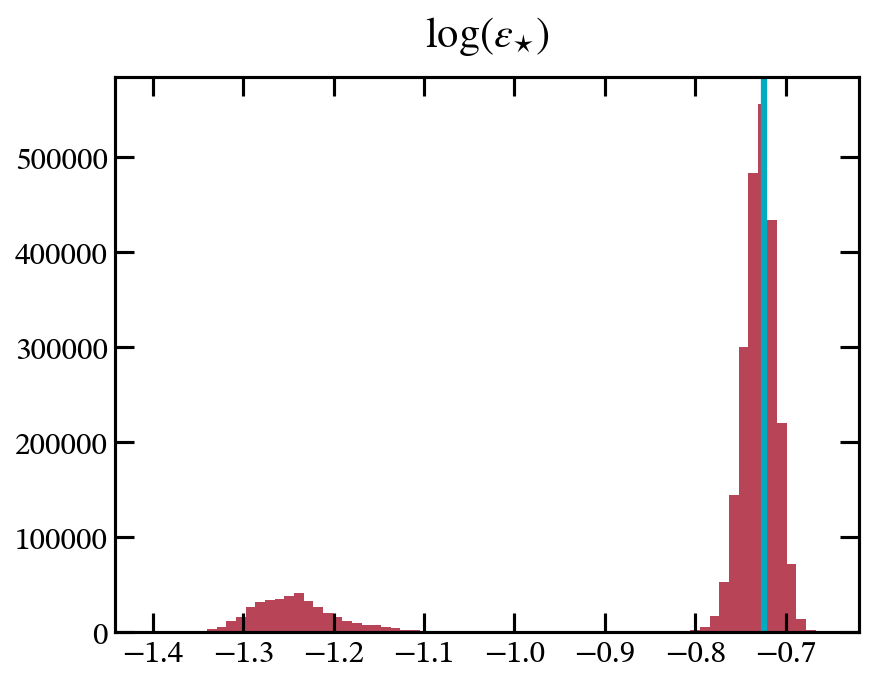

In [108]:
index = 4
fig, ax = plt.subplots()
hist = ax.hist(samples[:,index], bins = 70)
ax.set_title(param_labels[index])
ax.axvline(best_fit[index], color = eplots.turquoise)
# ax.axvline(-0.22, color = eplots.yellow)

In [109]:
selected_idxs = samples[:,index] > -1
print(f'{round(len(samples[selected_idxs])/1e6, 2)} million points kept')

2.3 million points kept


In [110]:
samples_selected = samples[selected_idxs]
samples_not_selected = samples[~selected_idxs]

In [111]:
bounds_selected = np.percentile(samples_selected, [16, 84], axis = 0)
bounds_not_selected = np.percentile(samples_not_selected, [16, 84], axis = 0)

In [112]:
bf_selected = samples_selected[np.argmax(log_prob[selected_idxs])]
bf_not_selected = samples_not_selected[np.argmax(log_prob[~selected_idxs])]

In [113]:
comparison_dict= {'fit': [bf_selected, bf_not_selected],
                   'label': ['selected', 'not selected']}

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:252: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5, zorder = dat_zorder)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:252: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5, zorder = dat_zorder)


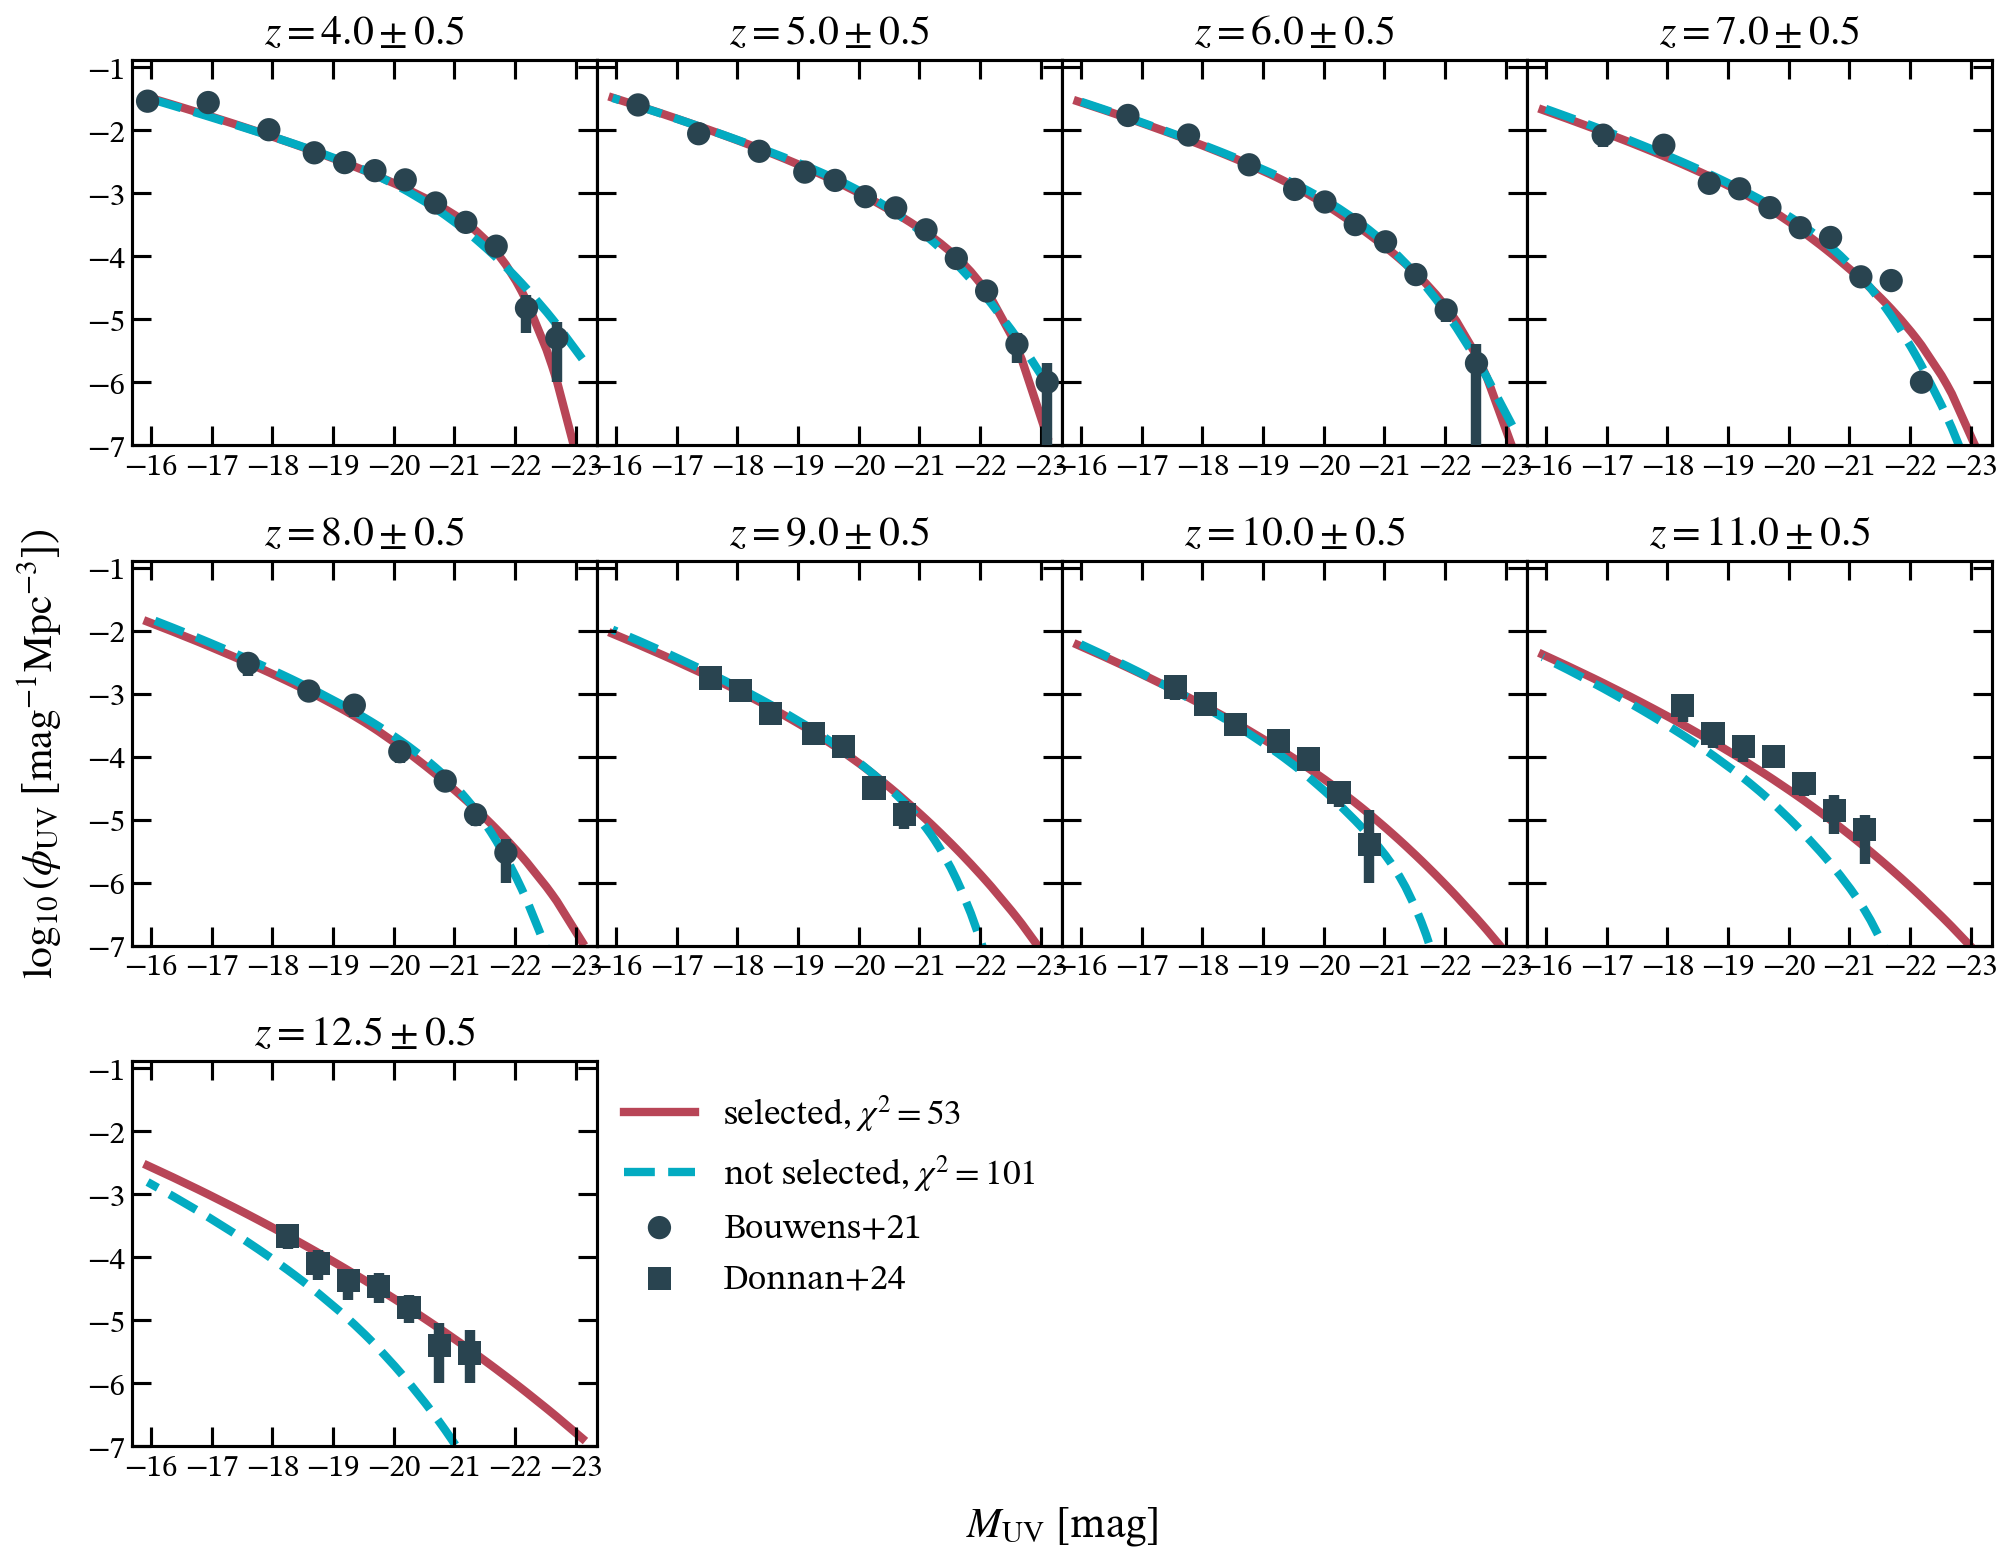

In [114]:
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_dict = comparison_dict)

In [115]:
def compare_fits(samples, fit_labels, best_fits, param_labels, ncols = 3, alpha = 0.5, bounds = None):
    assert(all([len(sample[0]) == len(samples[0][0]) for sample in samples])), 'The samples provided have different numbers of parameters'
    assert(len(param_labels) == len(samples[0][0])), 'The number of parameters doesn\'t match the number of parameters in the sample'
    
    n = len(param_labels)
    fig = plt.figure()
    gs = GridSpec(math.ceil((n+1)/ ncols), ncols, figure=fig)
    plt.subplots_adjust(hspace = 0.5)
    
    axs=[]
    colors = [eplots.turquoise, eplots.yellow]
    for i, label in enumerate(param_labels):
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)
        for sample, color, bf, fit_label in zip(samples, colors, best_fits, fit_labels):
            ax.hist(sample[:,i], alpha=alpha, density = False, label = fit_label, color = color)
            ax.axvline(bf[i], color = color, ls = 'dashed')
            ax.set_title(label)
        if bounds is not None:
            for bound, color in zip(bounds, colors):
                ax.axvline(bound[0][i], color = color, lw = 1,  ls = 'dotted')
                ax.axvline(bound[1][i], color = color, lw = 1,  ls = 'dotted')

    axs[0].plot(best_fits[0][0], 0, ls = 'dashed', color = 'black', label = 'best fit value')
    axs[0].plot(best_fits[0][0], 0, lw = 1, ls = 'dotted', color = 'black', label = 'upper/lower bounds')
    eplots.multicol(gs, axs, include_legend = True)

    return fig

In [116]:
ICs_selected = eMCMC.get_narrowed_ICs(my_UVLF, bf_selected, bounds_selected, labels = param_labels)
ICs_not_selected = eMCMC.get_narrowed_ICs(my_UVLF, bf_not_selected, bounds_not_selected, param_labels)

$\beta$ lower, -2.1352706989804537, out of bounds


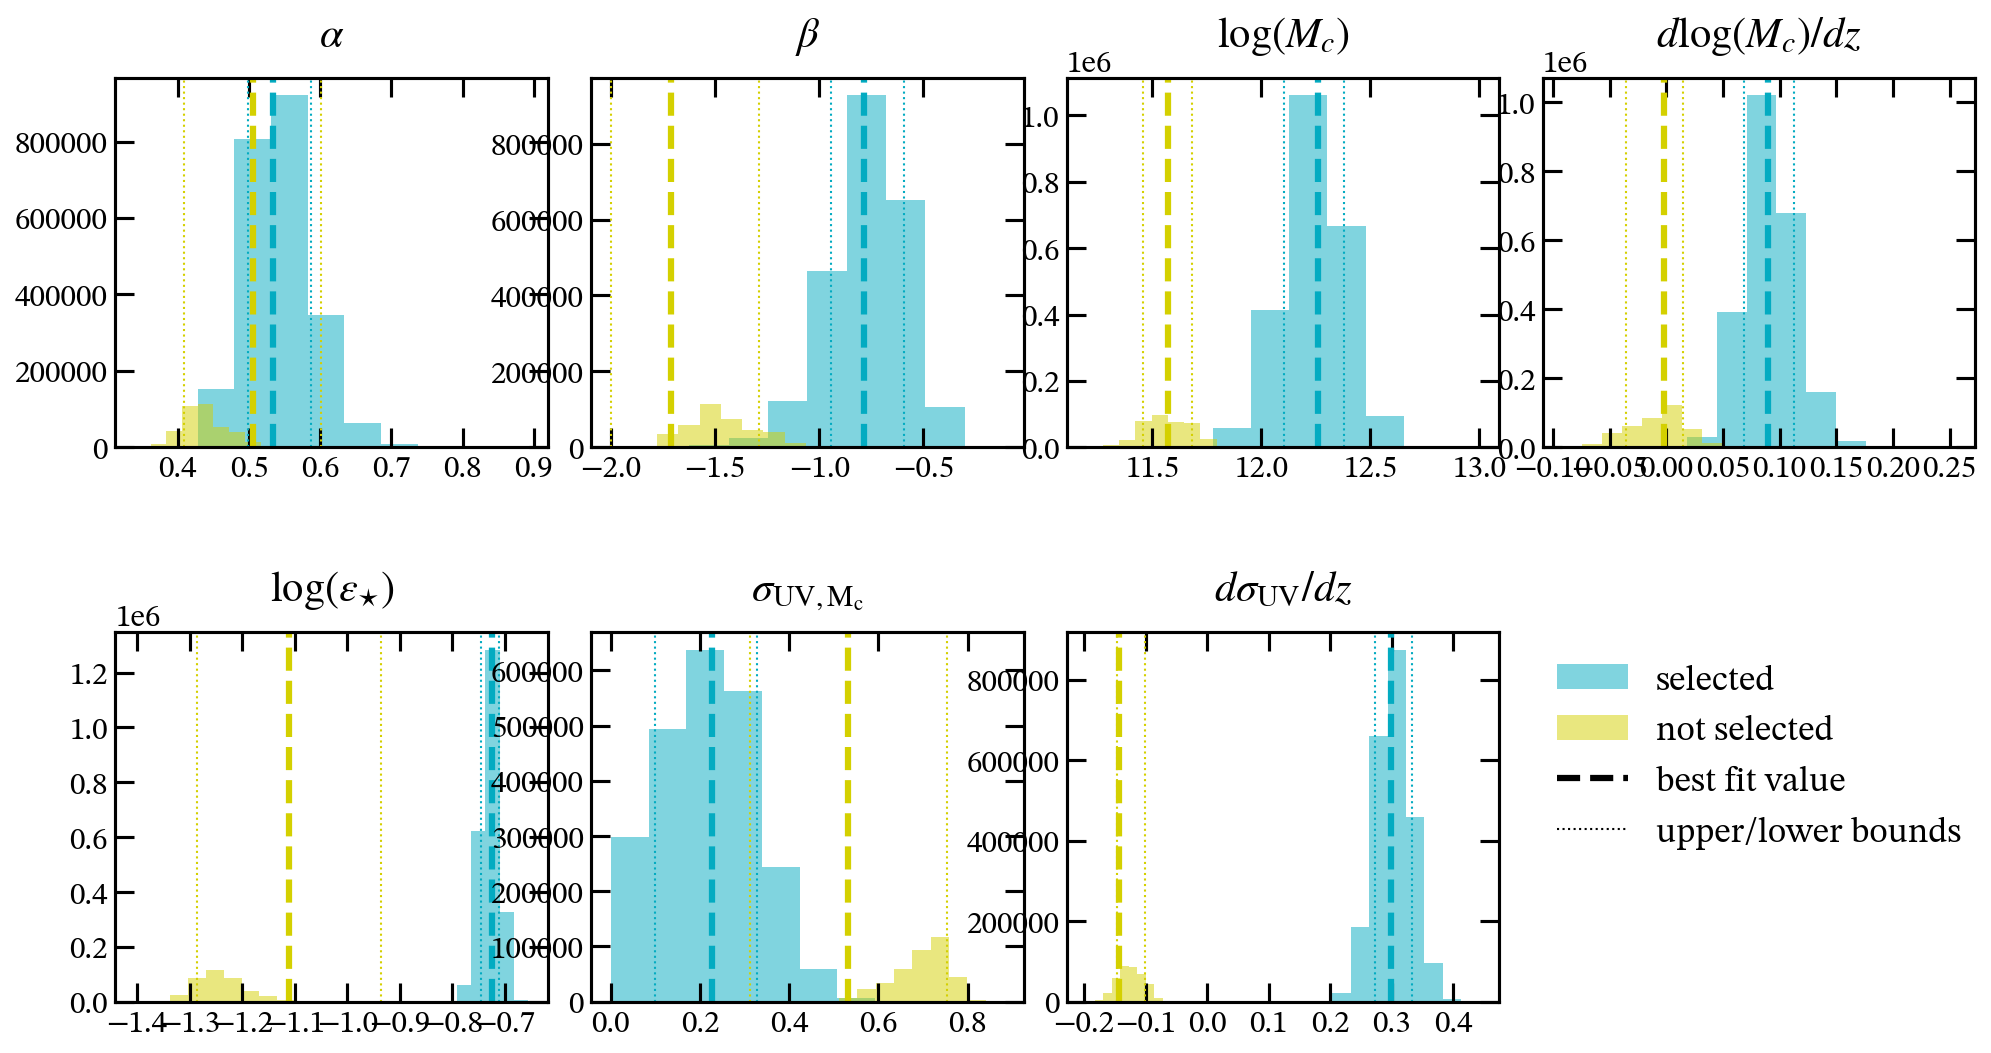

In [117]:
compare_fig = compare_fits([samples_selected, samples_not_selected], ['selected', 'not selected'], [bf_selected, bf_not_selected], param_labels, bounds = [ICs_selected, ICs_not_selected], ncols = 4)

In [118]:
param = 5

In [119]:
print(param_labels[param])

$\sigma_{\rm{UV}, M_c}$


In [120]:
print(f'{round(bf_selected[param], 2)}')
print(f'+ {round(bounds_selected[1][param]- bf_selected[param], 2)}')
print(f'{round(bounds_selected[0][param] - bf_selected[param], 2)}')

0.17
+ 0.12
-0.1


In [118]:
ICs_selected

(array([ 0.49851536, -0.94362656, 12.10156154,  0.06896894, -0.74608598,
         0.09891332,  0.27320848]),
 array([ 0.58685727, -0.59131342, 12.37826397,  0.11300032, -0.71127614,
         0.32740289,  0.33198093]))

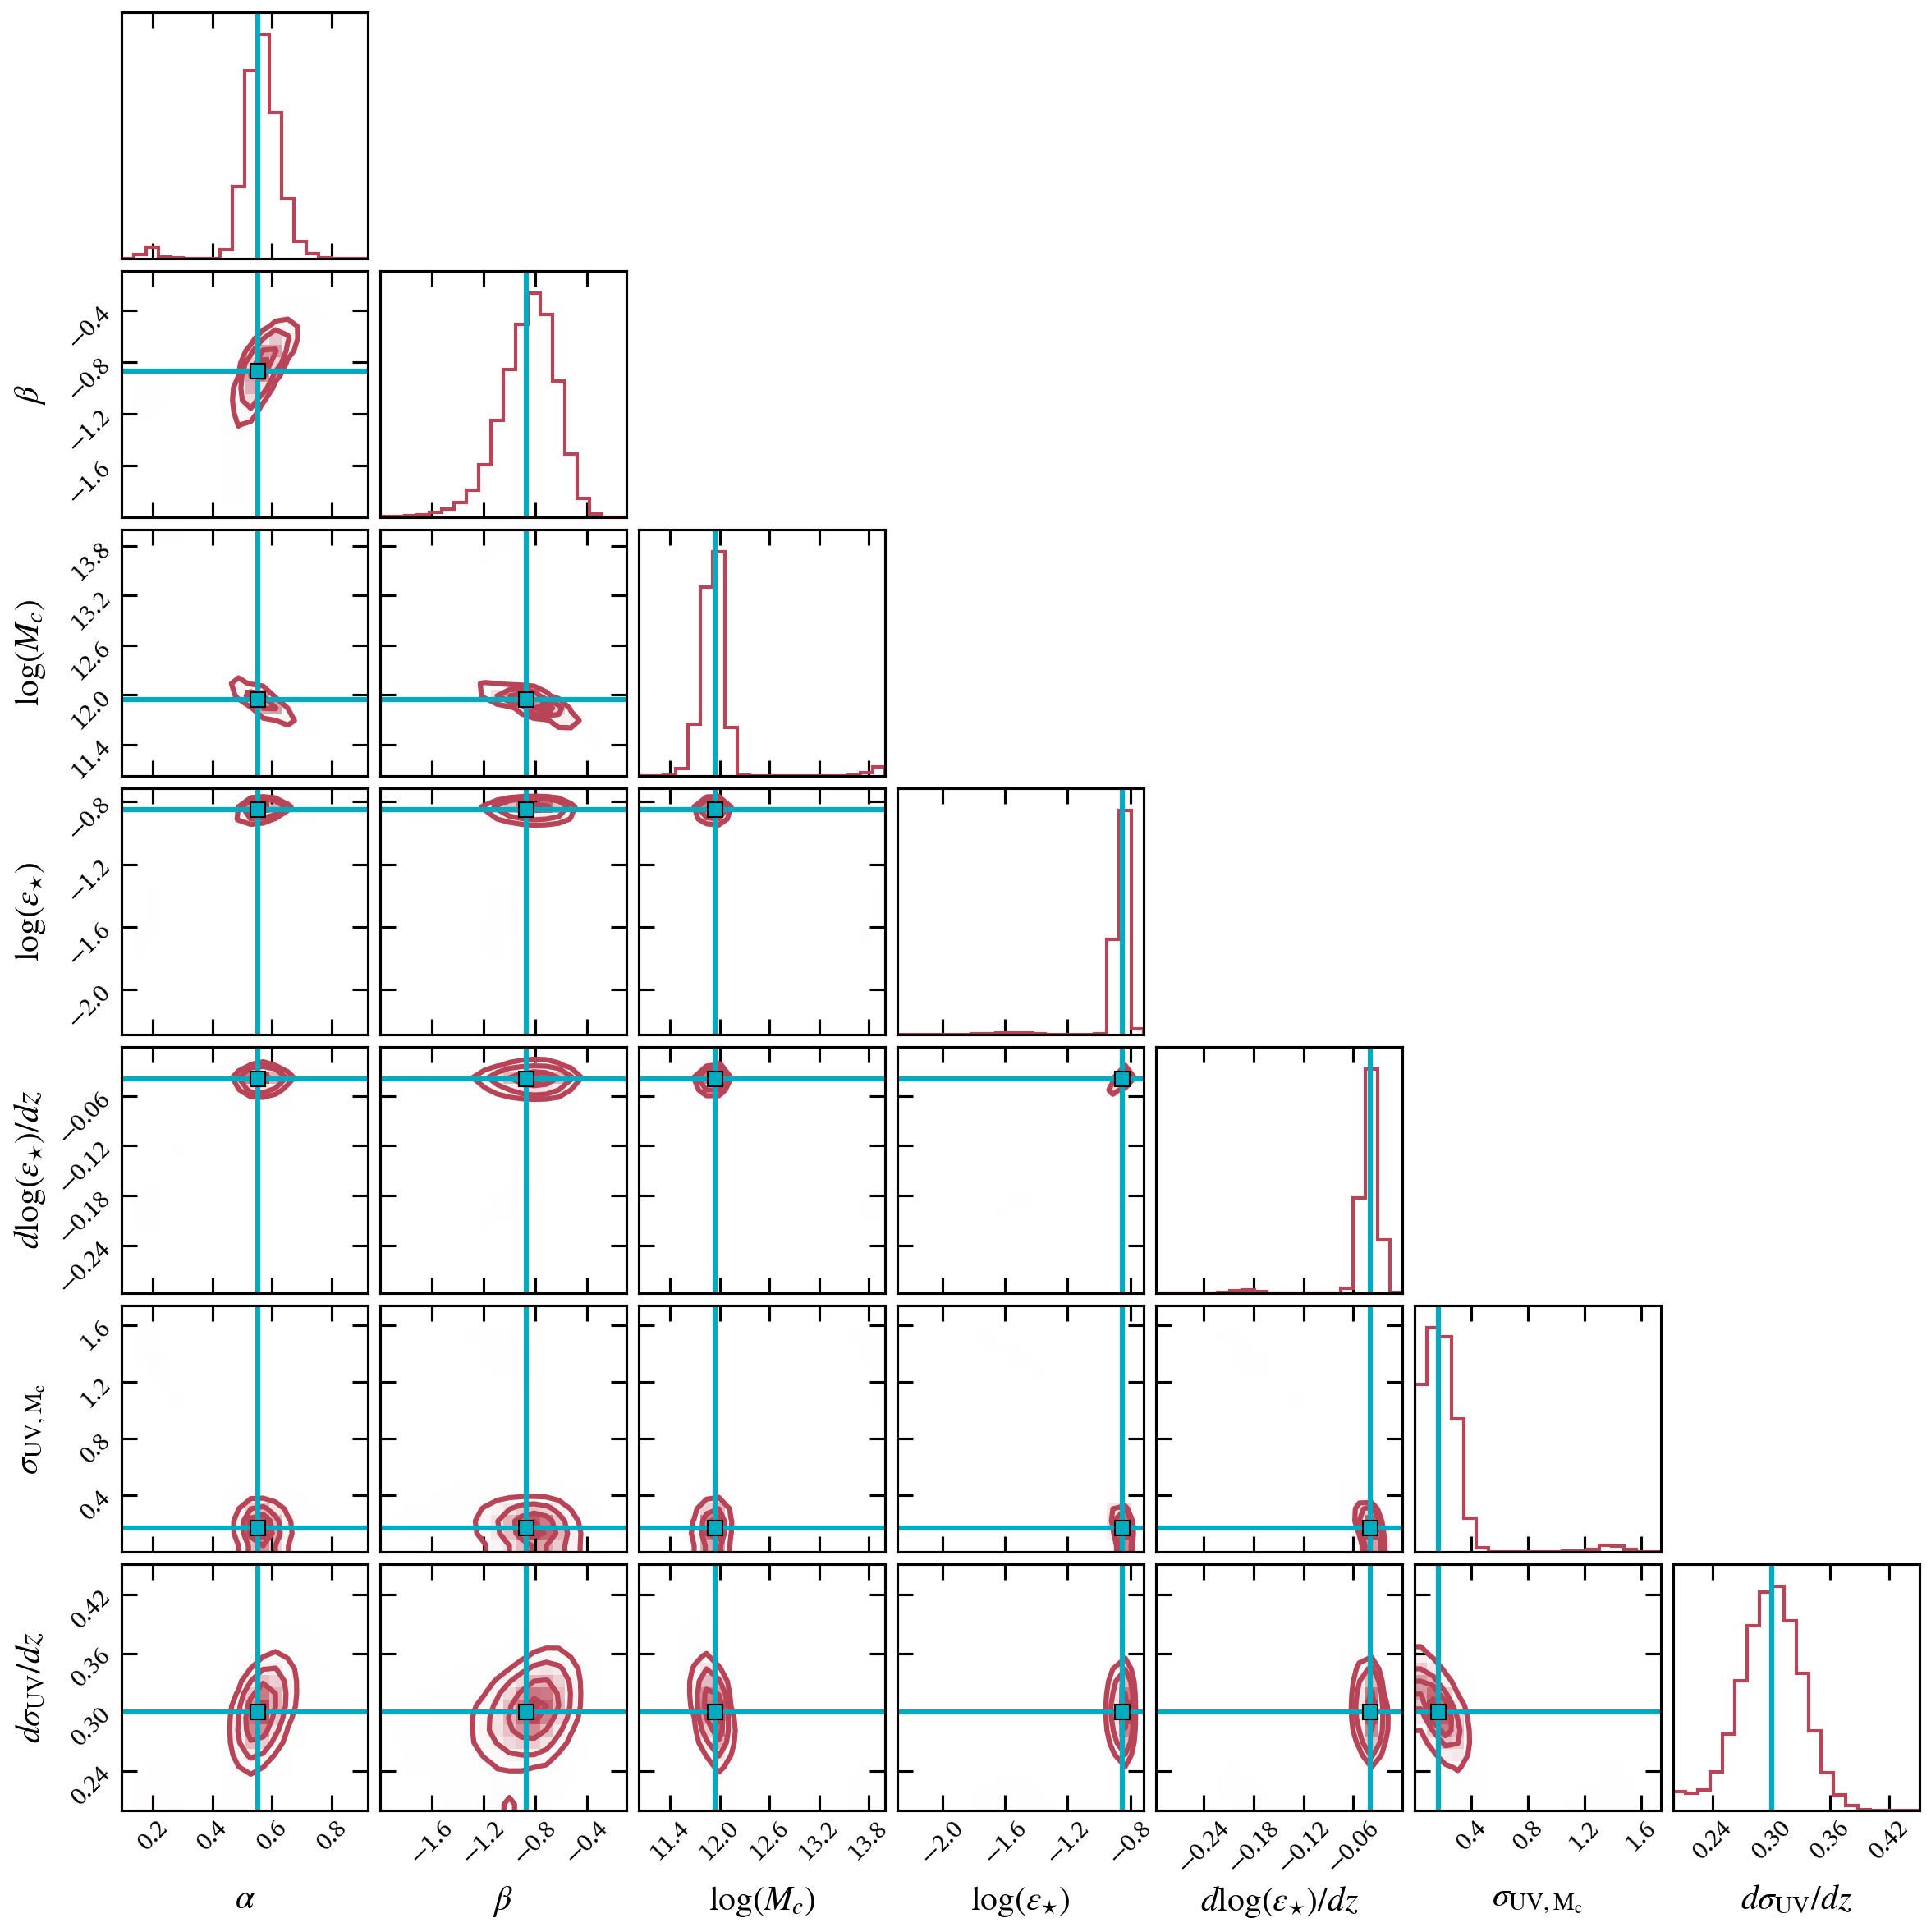

In [123]:
corner = eplots.make_corner(my_UVLF, samples = samples_selected, true_vals = bf_selected)

In [124]:
corner.savefig('/Users/eb35267/Desktop/code/figures/beta_constraints_narrow.png')